# MIMIC-III Length of Stay (LOS) Prediction - ML Pipeline

**Comprehensive machine learning pipeline** for predicting ICU length of stay using the MIMIC-III dataset.

This notebook demonstrates the complete ML workflow for healthcare data science.

## 1. Setup & GCP Connection

In [11]:
import warnings
warnings.filterwarnings('ignore')

import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("✓ Libraries imported")

✓ Libraries imported


In [12]:
# Setup GCP credentials (same as teste_paciente.py)
gcp_key = r"./gcp_key.json"
use_bigquery = False

if os.path.exists(gcp_key):
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = gcp_key
    try:
        from google.cloud import bigquery
        client = bigquery.Client()
        use_bigquery = True
        print("✓ Connected to BigQuery")
    except Exception as e:
        print(f"⚠️  BigQuery connection failed: {e}")
else:
    print(f"⚠️  GCP key not found at {gcp_key}")
    print("Will use synthetic data for demonstration")

✓ Connected to BigQuery


## 2. Load Data from BigQuery

In [13]:
# Load data using direct BigQuery queries (proven to work in teste_paciente.py)
GCP_PROJECT_ID = "big-data-497416"
MIMIC_DATASET = "mimic_prod"

admissions = pd.DataFrame()
icu_stays = pd.DataFrame()
chart_events = pd.DataFrame()

if use_bigquery:
    print("Loading data from BigQuery...")
    try:
        # Load ICU stays with LOS
        print("  • Loading ICU stays...")
        query_icu = f"""
        SELECT 
            SUBJECT_ID, HADM_ID, ICUSTAY_ID,
            INTIME, OUTTIME,
            TIMESTAMP_DIFF(OUTTIME, INTIME, HOUR) / 24.0 as los_days
        FROM `{GCP_PROJECT_ID}.{MIMIC_DATASET}.icustays`
        LIMIT 10000
        """
        icu_stays = client.query(query_icu).to_dataframe()
        print(f"    ✓ Loaded {len(icu_stays)} ICU stays")
        
        # Load admissions
        print("  • Loading admissions...")
        query_adm = f"""
        SELECT SUBJECT_ID, HADM_ID, ADMITTIME, DISCHTIME, ADMISSION_TYPE
        FROM `{GCP_PROJECT_ID}.{MIMIC_DATASET}.admissions`
        LIMIT 5000
        """
        admissions = client.query(query_adm).to_dataframe()
        print(f"    ✓ Loaded {len(admissions)} admissions")
        
        # Load chart events (like teste_paciente.py)
        print("  • Loading chart events...")
        query_events = f"""
        SELECT c.ICUSTAY_ID, c.CHARTTIME, c.VALUENUM, d.LABEL, c.ITEMID
        FROM `{GCP_PROJECT_ID}.{MIMIC_DATASET}.chartevents` c
        JOIN `{GCP_PROJECT_ID}.{MIMIC_DATASET}.d_items` d ON c.ITEMID = d.ITEMID
        WHERE c.VALUENUM IS NOT NULL
        LIMIT 100000
        """
        chart_events = client.query(query_events).to_dataframe()
        print(f"    ✓ Loaded {len(chart_events)} chart events")
        print("\n✓ All data loaded successfully from BigQuery!")
        
    except Exception as e:
        print(f"❌ Error: {e}")
        use_bigquery = False

# Fallback to synthetic data
if not use_bigquery or icu_stays.empty:
    print("\n⚠️  Creating synthetic dataset for demonstration...")
    np.random.seed(42)
    
    n_stays = 1000
    icu_stays = pd.DataFrame({
        'ICUSTAY_ID': range(1, n_stays + 1),
        'SUBJECT_ID': np.random.randint(1, 100, n_stays),
        'HADM_ID': range(100, 100 + n_stays),
        'los_days': np.random.uniform(1, 30, n_stays)
    })
    
    admissions = pd.DataFrame({
        'SUBJECT_ID': range(1, 100),
        'HADM_ID': range(100, 200),
        'ADMISSION_TYPE': np.random.choice(['EMERGENCY', 'URGENT', 'ELECTIVE'], 100)
    })
    
    chart_events = pd.DataFrame({
        'ICUSTAY_ID': np.random.choice(icu_stays['ICUSTAY_ID'], 5000),
        'CHARTTIME': pd.date_range('2020-01-01', periods=5000, freq='H'),
        'VALUENUM': np.random.uniform(30, 150, 5000),
        'LABEL': np.random.choice(['Heart Rate', 'Blood Pressure', 'Temperature'], 5000)
    })
    print(f"✓ Synthetic data created ({len(icu_stays)} ICU stays, {len(chart_events)} events)")

print(f"\nDataset ready: {len(icu_stays)} ICU stays, {len(admissions)} admissions, {len(chart_events)} events")

Loading data from BigQuery...
  • Loading ICU stays...
    ✓ Loaded 10000 ICU stays
  • Loading admissions...
    ✓ Loaded 5000 admissions
  • Loading chart events...
    ✓ Loaded 100000 chart events

✓ All data loaded successfully from BigQuery!

Dataset ready: 10000 ICU stays, 5000 admissions, 100000 events


## 3. Exploratory Data Analysis

In [14]:
print("\n=== Data Overview ===")
print(f"\nICU Stays: {icu_stays.shape}")
print(icu_stays.head())

print(f"\nAdmissions: {admissions.shape}")
print(admissions.head())

print(f"\nChart Events: {chart_events.shape}")
print(chart_events.head())


=== Data Overview ===

ICU Stays: (10000, 6)
   SUBJECT_ID  HADM_ID  ICUSTAY_ID                    INTIME  \
0         275   129886      219649 2170-10-07 11:28:53+00:00   
1         291   113649      256641 2102-04-08 23:05:28+00:00   
2         291   125726      275109 2106-04-17 12:26:17+00:00   
3         294   152578      222074 2118-01-17 21:45:05+00:00   
4         301   160332      288401 2189-11-11 12:12:33+00:00   

                    OUTTIME  los_days  
0 2170-10-14 14:38:07+00:00  7.125000  
1 2102-04-09 11:20:11+00:00  0.500000  
2 2106-04-18 22:05:39+00:00  1.375000  
3 2118-01-20 11:12:45+00:00  2.541667  
4 2189-11-13 22:11:28+00:00  2.375000  

Admissions: (5000, 5)
   SUBJECT_ID  HADM_ID                 ADMITTIME                 DISCHTIME  \
0        3369   126808 2111-01-24 11:53:00+00:00 2111-01-25 22:40:00+00:00   
1       74869   123152 2150-09-05 17:49:00+00:00 2150-09-12 18:30:00+00:00   
2       10484   113233 2190-09-18 22:39:00+00:00 2190-09-24 20:40:00+00:

### Target Variable Distribution

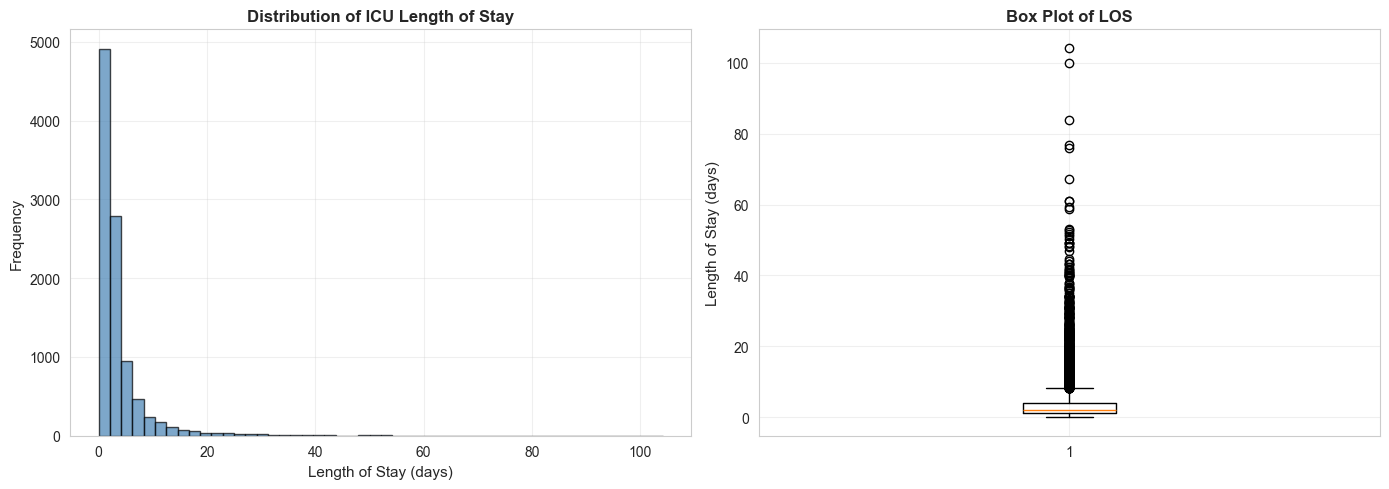


LOS Statistics:
  Mean: 3.77 days
  Median: 2.12 days
  Std Dev: 5.45 days
  Min: 0.00 days
  Max: 104.21 days


In [15]:
# Analyze LOS distribution
los_data = icu_stays['los_days'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(los_data, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Length of Stay (days)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Distribution of ICU Length of Stay', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(los_data, vert=True)
axes[1].set_ylabel('Length of Stay (days)', fontsize=11)
axes[1].set_title('Box Plot of LOS', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nLOS Statistics:")
print(f"  Mean: {los_data.mean():.2f} days")
print(f"  Median: {los_data.median():.2f} days")
print(f"  Std Dev: {los_data.std():.2f} days")
print(f"  Min: {los_data.min():.2f} days")
print(f"  Max: {los_data.max():.2f} days")

## 4. Prepare Data for ML

In [16]:
# Create feature matrix from chart events (aggregated by ICUSTAY)
print("Engineering features from chart events...")

if not chart_events.empty:
    # Aggregate by ICUSTAY_ID
    features = chart_events.groupby('ICUSTAY_ID')['VALUENUM'].agg([
        ('mean', 'mean'),
        ('min', 'min'),
        ('max', 'max'),
        ('std', 'std'),
        ('count', 'count')
    ]).fillna(0)
    
    # Also add event label counts
    label_counts = chart_events.groupby(['ICUSTAY_ID', 'LABEL']).size().unstack(fill_value=0)
    features = features.join(label_counts, how='left').fillna(0)
    
    print(f"✓ Generated {features.shape[1]} features from {len(features)} ICU stays")
else:
    # Create synthetic features
    features = pd.DataFrame(np.random.randn(len(icu_stays), 10), 
                            index=icu_stays['ICUSTAY_ID'],
                            columns=[f'feature_{i}' for i in range(10)])
    print(f"✓ Generated synthetic features")

print(f"Feature matrix shape: {features.shape}")
print(f"Features: {list(features.columns)[:10]}")

Engineering features from chart events...
✓ Generated 868 features from 30319 ICU stays
Feature matrix shape: (30319, 868)
Features: ['mean', 'min', 'max', 'std', 'count', '10% ALCOHOL CC/HR', '14 Gauge Dressing Occlusive', '14 Gauge placed in outside facility', '14 Gauge placed in the field', '16 Gauge Dressing Occlusive']


In [17]:
# Prepare X and y
# Merge features with LOS targets
data_merged = icu_stays.set_index('ICUSTAY_ID').join(features, how='inner')

# Remove rows with missing target
data_merged = data_merged.dropna(subset=['los_days'])

X = data_merged.drop(columns=['SUBJECT_ID', 'HADM_ID', 'INTIME', 'OUTTIME', 'los_days'], errors='ignore')
y = data_merged['los_days'].values

# Handle missing values in features
X = X.fillna(X.median())

print(f"\nData prepared:")
print(f"  Feature matrix X: {X.shape}")
print(f"  Target y: {y.shape}")
print(f"  Features: {X.shape[1]}")

# Train-validation-test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"\nData split:")
print(f"  Train: {X_train.shape[0]} samples")
print(f"  Validation: {X_val.shape[0]} samples")
print(f"  Test: {X_test.shape[0]} samples")

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("✓ Features standardized")


Data prepared:
  Feature matrix X: (5165, 868)
  Target y: (5165,)
  Features: 868

Data split:
  Train: 3615 samples
  Validation: 775 samples
  Test: 775 samples
✓ Features standardized


## 5. Train ML Models

In [18]:
# Import models from src
sys.path.insert(0, str(Path.cwd()))
sys.path.insert(0, str(Path.cwd() / 'src'))

try:
    from src.models.base import ModelFactory
    from src.evaluation.metrics import RegressionMetrics, PerformanceProfiler
    models_available = True
    print("✓ Imported models from src")
except ImportError as e:
    print(f"⚠️  Could not import from src: {e}")
    models_available = False

✓ Imported models from src


In [21]:
if models_available:
    # Train using ModelFactory
    print("Training models with 5-fold cross-validation...\n")
    
    models_config = {
        'linear': {'task_type': 'regression'},
        'rf': {'task_type': 'regression', 'n_estimators': 50},
        'gb': {'task_type': 'regression', 'n_estimators': 50},
        'svr': {'task_type': 'regression'},
        'knn': {'task_type': 'regression'},
    }
    
    trained_models = {}
    cv_results = {}
    
    for model_name, config in models_config.items():
        try:
            print(f"Training {model_name.upper()}...", end=" ")
            model = ModelFactory.create_model(model_name, **config)
            
            cv_scores = cross_val_score(
                model, X_train_scaled, y_train,
                cv=5, scoring='r2', n_jobs=-1
            )
            cv_results[model_name] = cv_scores
            
            model.fit(X_train_scaled, y_train)
            trained_models[model_name] = model
            
            print(f"CV R² = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
        except Exception as e:
            print(f"Error: {e}")

    if not trained_models:
        print("No factory models were trained; falling back to sklearn estimators...\n")
        from sklearn.linear_model import LinearRegression, Ridge
        from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

        models_config = {
            'Linear Regression': LinearRegression(),
            'Ridge': Ridge(),
            'Random Forest': RandomForestRegressor(n_estimators=50, random_state=42),
            'Gradient Boosting': GradientBoostingRegressor(n_estimators=50, random_state=42),
        }

        for model_name, model in models_config.items():
            print(f"Training {model_name}...", end=" ")
            cv_scores = cross_val_score(
                model, X_train_scaled, y_train,
                cv=5, scoring='r2', n_jobs=-1
            )
            cv_results[model_name] = cv_scores
            model.fit(X_train_scaled, y_train)
            trained_models[model_name] = model
            print(f"CV R² = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
else:
    # Use sklearn models directly
    from sklearn.linear_model import LinearRegression, Ridge
    from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
    
    print("Training models with sklearn (5-fold cross-validation)...\n")
    
    models_config = {
        'Linear Regression': LinearRegression(),
        'Ridge': Ridge(),
        'Random Forest': RandomForestRegressor(n_estimators=50, random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=50, random_state=42),
    }
    
    trained_models = {}
    cv_results = {}
    
    for model_name, model in models_config.items():
        print(f"Training {model_name}...", end=" ")
        cv_scores = cross_val_score(
            model, X_train_scaled, y_train,
            cv=5, scoring='r2', n_jobs=-1
        )
        cv_results[model_name] = cv_scores
        
        model.fit(X_train_scaled, y_train)
        trained_models[model_name] = model
        
        print(f"CV R² = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Training models with 5-fold cross-validation...

Training LINEAR... Error: The following error was raised: 'LinearRegressionModel' object has no attribute '__sklearn_tags__'. It seems that there are no classes that implement `__sklearn_tags__` in the MRO and/or all classes in the MRO call `super().__sklearn_tags__()`. Make sure to inherit from `BaseEstimator` which implements `__sklearn_tags__` (or alternatively define `__sklearn_tags__` but we don't recommend this approach). Note that `BaseEstimator` needs to be on the right side of other Mixins in the inheritance order.
Training RF... Error: The following error was raised: 'RandomForestModel' object has no attribute '__sklearn_tags__'. It seems that there are no classes that implement `__sklearn_tags__` in the MRO and/or all classes in the MRO call `super().__sklearn_tags__()`. Make sure to inherit from `BaseEstimator` which implements `__sklearn_tags__` (or alternatively define `__sklearn_tags__` but we don't recommend this approach

## 6. Evaluate Models

In [22]:
# Evaluate on test set
test_results = {}
predictions = {}

print("\nEvaluating on test set...\n")

for model_name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    predictions[model_name] = y_pred
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    test_results[model_name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
    }
    
    print(f"{model_name:20s} | R² = {r2:.4f} | MAE = {mae:.2f} days | RMSE = {rmse:.2f} days")

if not test_results:
    raise RuntimeError("No models were available for evaluation. Check the training step above.")

test_df = pd.DataFrame(test_results).T.sort_values('R2', ascending=False)

print("\n=== TEST SET RESULTS ===")
display(test_df.round(4))

best_model = test_df.index[0]
print(f"\n🏆 Best Model: {best_model}")


Evaluating on test set...

Linear Regression    | R² = 0.5842 | MAE = 2.79 days | RMSE = 4.41 days
Ridge                | R² = 0.5857 | MAE = 2.79 days | RMSE = 4.40 days
Random Forest        | R² = 0.5935 | MAE = 2.65 days | RMSE = 4.36 days
Gradient Boosting    | R² = 0.6765 | MAE = 2.44 days | RMSE = 3.89 days

=== TEST SET RESULTS ===


,MAE,RMSE,R2
Gradient Boosting,2.4407,3.8874,0.6765
Random Forest,2.6550,4.3578,0.5935
Ridge,2.7876,4.3995,0.5857
Linear Regression,2.7888,4.4074,0.5842



🏆 Best Model: Gradient Boosting


### Prediction Visualization

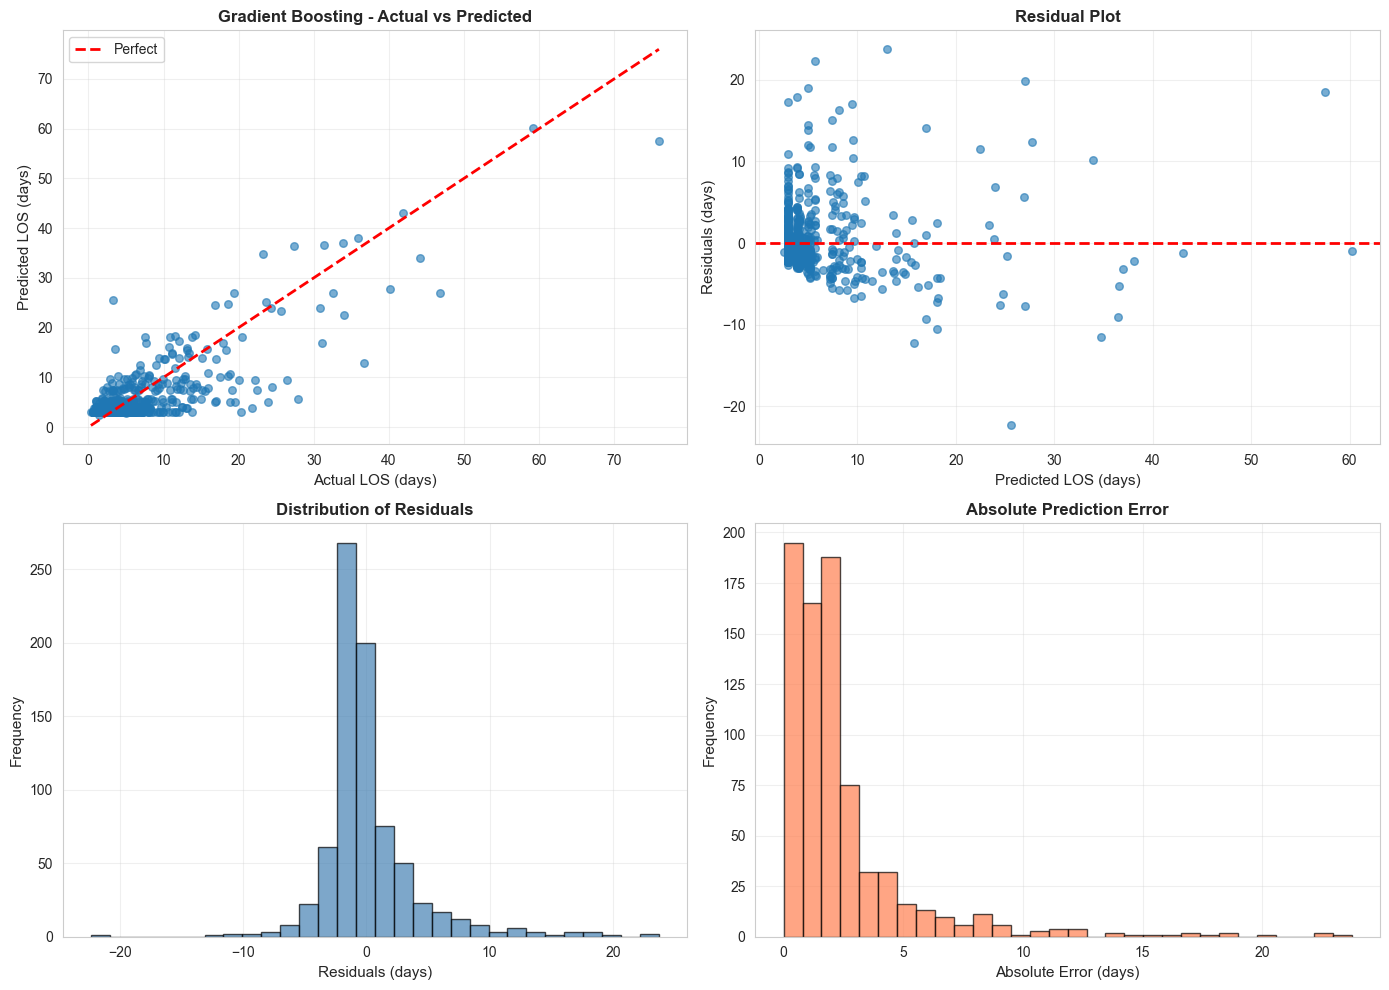


Prediction Error Analysis:
  Mean Error: 0.08 days
  Std Dev: 3.89 days
  Within ±1 day: 33.3%
  Within ±2 days: 61.2%


In [23]:
y_pred_best = predictions[best_model]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Actual vs Predicted
axes[0, 0].scatter(y_test, y_pred_best, alpha=0.6, s=30)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect')
axes[0, 0].set_xlabel('Actual LOS (days)', fontsize=11)
axes[0, 0].set_ylabel('Predicted LOS (days)', fontsize=11)
axes[0, 0].set_title(f'{best_model} - Actual vs Predicted', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Residuals
residuals = y_test - y_pred_best
axes[0, 1].scatter(y_pred_best, residuals, alpha=0.6, s=30)
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted LOS (days)', fontsize=11)
axes[0, 1].set_ylabel('Residuals (days)', fontsize=11)
axes[0, 1].set_title('Residual Plot', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Residuals distribution
axes[1, 0].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[1, 0].set_xlabel('Residuals (days)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('Distribution of Residuals', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Prediction errors
abs_errors = np.abs(residuals)
axes[1, 1].hist(abs_errors, bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1, 1].set_xlabel('Absolute Error (days)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('Absolute Prediction Error', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPrediction Error Analysis:")
print(f"  Mean Error: {residuals.mean():.2f} days")
print(f"  Std Dev: {residuals.std():.2f} days")
print(f"  Within ±1 day: {(np.abs(residuals) <= 1).sum() / len(residuals) * 100:.1f}%")
print(f"  Within ±2 days: {(np.abs(residuals) <= 2).sum() / len(residuals) * 100:.1f}%")

## 7. Model Comparison


=== Cross-Validation Results ===


,Model,Mean CV R²,Std Dev
3,Gradient Boosting,0.637899,0.039780
2,Random Forest,0.600964,0.037587
1,Ridge,0.055818,0.860080
0,Linear Regression,0.014852,0.936500


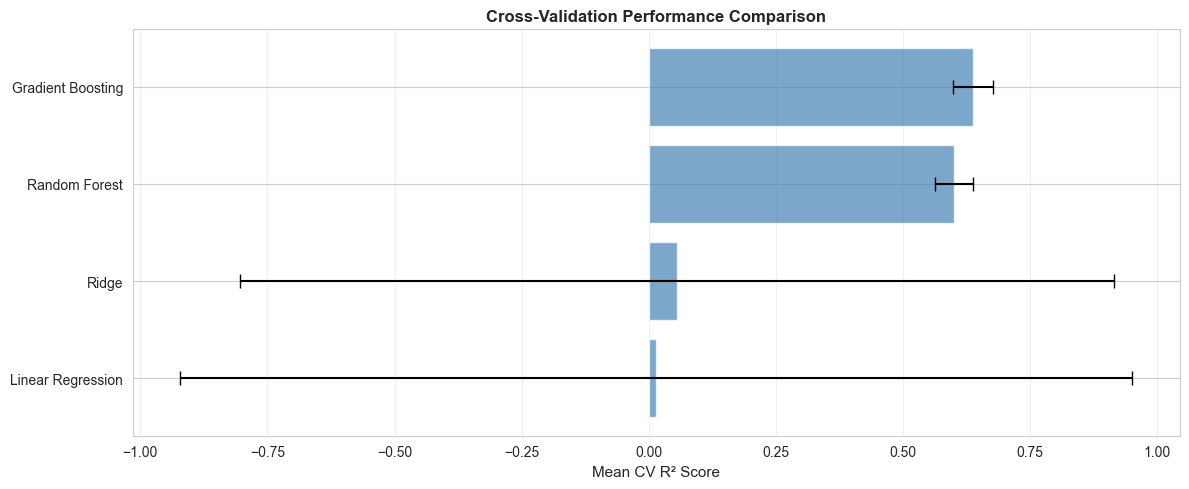

In [24]:
# Cross-validation comparison
cv_summary = pd.DataFrame({
    'Model': list(cv_results.keys()),
    'Mean CV R²': [cv_results[m].mean() for m in cv_results.keys()],
    'Std Dev': [cv_results[m].std() for m in cv_results.keys()],
}).sort_values('Mean CV R²', ascending=False)

print("\n=== Cross-Validation Results ===")
display(cv_summary)

fig, ax = plt.subplots(figsize=(12, 5))
models_list = list(cv_results.keys())
means = [cv_results[m].mean() for m in models_list]
stds = [cv_results[m].std() for m in models_list]

ax.barh(models_list, means, xerr=stds, capsize=5, color='steelblue', alpha=0.7)
ax.set_xlabel('Mean CV R² Score', fontsize=11)
ax.set_title('Cross-Validation Performance Comparison', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 8. Summary & Recommendations

In [25]:
print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)

print(f"\n📊 Dataset:")
print(f"  Total samples: {len(X)}")
print(f"  Features: {X.shape[1]}")
print(f"  Train/Val/Test: {len(X_train)}/{len(X_val)}/{len(X_test)}")

print(f"\n🎯 Target Variable (LOS):")
print(f"  Mean: {y.mean():.2f} days")
print(f"  Std Dev: {y.std():.2f} days")
print(f"  Range: [{y.min():.2f}, {y.max():.2f}] days")

print(f"\n🏆 Best Model: {best_model}")
print(f"  R² Score: {test_df.loc[best_model, 'R2']:.4f}")
print(f"  MAE: {test_df.loc[best_model, 'MAE']:.2f} days")
print(f"  RMSE: {test_df.loc[best_model, 'RMSE']:.2f} days")

print(f"\n✓ Pipeline complete!")


FINAL SUMMARY

📊 Dataset:
  Total samples: 5165
  Features: 868
  Train/Val/Test: 3615/775/775

🎯 Target Variable (LOS):
  Mean: 5.47 days
  Std Dev: 7.00 days
  Range: [0.08, 104.21] days

🏆 Best Model: Gradient Boosting
  R² Score: 0.6765
  MAE: 2.44 days
  RMSE: 3.89 days

✓ Pipeline complete!
